Loading Mall Customers dataset from local file...

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

First 5 Rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                

c:\Users\S SATHWICK\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\S SATHWICK\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\S SATHWICK\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\S SATHWICK\AppData\Local\Programs\Python\Python313\Lib\subpr

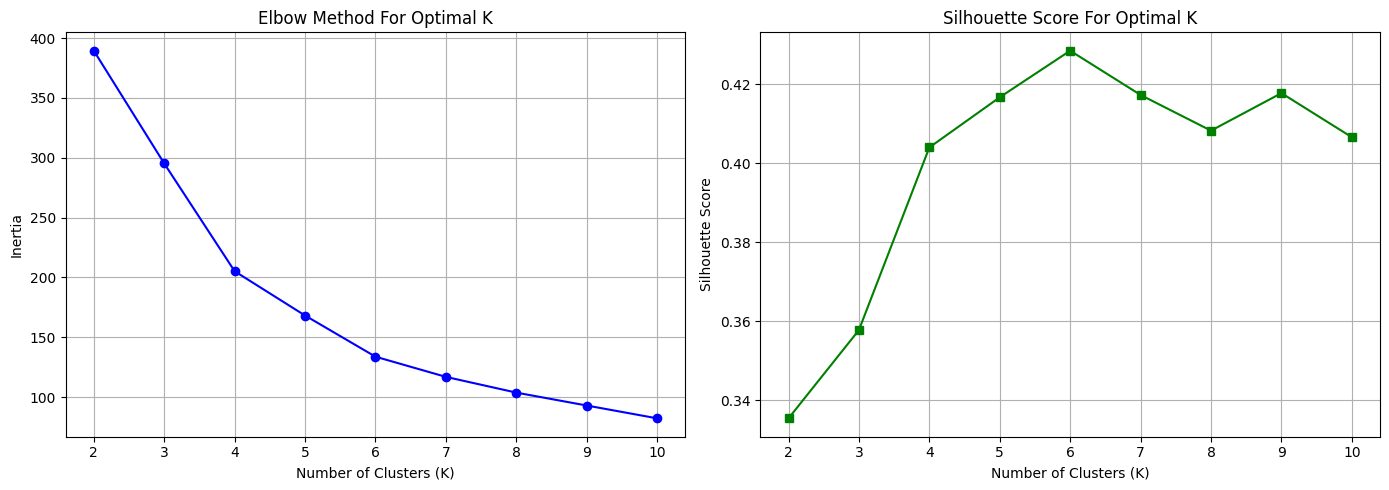


Explained Variance Ratio of PCA components:
[0.44266167 0.33308378]


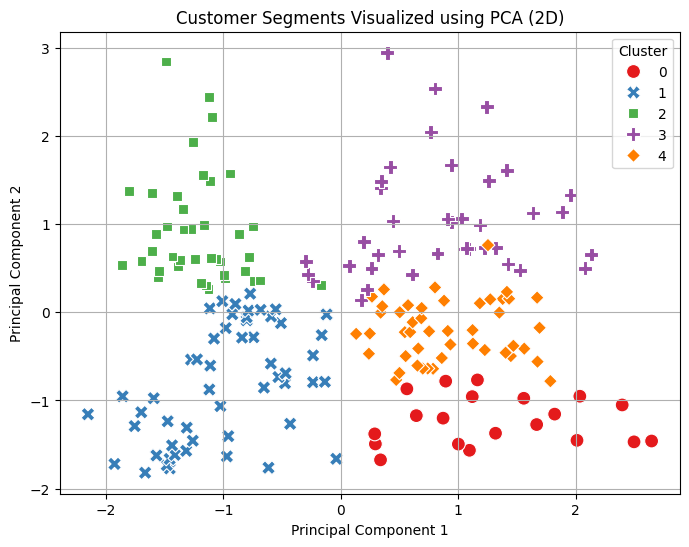


Cluster Means (Original Scale):
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        46.250000           26.750000               18.350000
1        25.185185           41.092593               62.240741
2        32.875000           86.100000               81.525000
3        39.871795           86.102564               19.358974
4        55.638298           54.382979               48.851064


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ---------------------------------------------------------
# Step 1: Load Dataset from Local File
# ---------------------------------------------------------
print("Loading Mall Customers dataset from local file...")
csv_path = "Mall_Customers.csv"
df = pd.read_csv(csv_path)

print("\nDataset Info:")
print(df.info())
print("\nFirst 5 Rows:")
print(df.head())

# ---------------------------------------------------------
# Step 2: Feature Selection & Preprocessing
# ---------------------------------------------------------
# Selecting numerical features for clustering: Age, Annual Income, Spending Score
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------------------------------------
# Step 3: Find Optimal K (Elbow Method & Silhouette Score)
# ---------------------------------------------------------
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow Method & Silhouette Scores
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Plot
ax[0].plot(range(2, 11), inertia, marker='o', color='b')
ax[0].set_title('Elbow Method For Optimal K')
ax[0].set_xlabel('Number of Clusters (K)')
ax[0].set_ylabel('Inertia')
ax[0].grid(True)

# Silhouette Score Plot
ax[1].plot(K_range, silhouette_scores, marker='s', color='g')
ax[1].set_title('Silhouette Score For Optimal K')
ax[1].set_xlabel('Number of Clusters (K)')
ax[1].set_ylabel('Silhouette Score')
ax[1].grid(True)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Step 4: Apply K-Means Clustering (Optimal K = 5)
# ---------------------------------------------------------
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# ---------------------------------------------------------
# Step 5: Dimensionality Reduction using PCA
# ---------------------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

print("\nExplained Variance Ratio of PCA components:")
print(pca.explained_variance_ratio_)

# ---------------------------------------------------------
# Step 6: Visualizing Clusters in 2D PCA Space
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='PC1', y='PC2', hue='Cluster', data=df, 
    palette='Set1', style='Cluster', s=100
)
plt.title('Customer Segments Visualized using PCA (2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# Step 7: Cluster Profile Analysis
# ---------------------------------------------------------
cluster_summary = df.groupby('Cluster')[features].mean()
print("\nCluster Means (Original Scale):")
print(cluster_summary)
